In [27]:
from ddgs import DDGS #DuckDuckGo has changed the api so we need to update 
from fastcore.all import *

def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
import time, json


In [2]:
urls = search_images('Human photos', max_images=1)
urls[0]

'https://images.pexels.com/photos/1239291/pexels-photo-1239291.jpeg?cs=srgb&dl=pexels-danxavier-1239291.jpg&fm=jpg'

In [4]:
urls = search_images('Animal photos', max_images=1)
urls[0]

'https://images.pexels.com/photos/247376/pexels-photo-247376.jpeg?cs=srgb&dl=africa-animals-conservation-247376.jpg&fm=jpg'

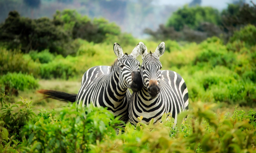

In [5]:
from fastdownload import download_url
dest = './Animal.jpg'
download_url(urls[0], dest, show_progress=False)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256, 256)


In [32]:
searches = 'Human','Animal'
path = Path('Human_vs_Animal')

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

In [29]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

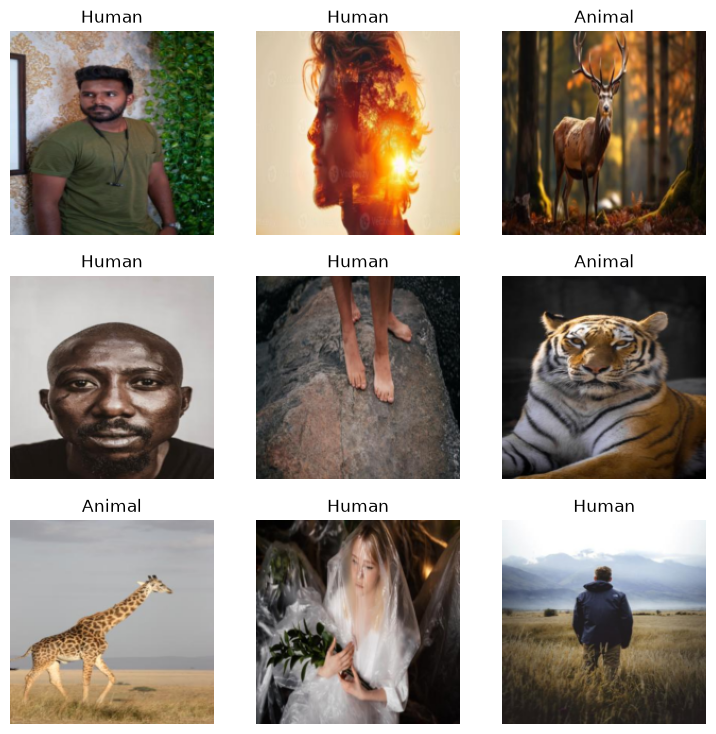

In [33]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch()

In [9]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(10)

epoch,train_loss,valid_loss,error_rate,time
0,1.127552,1.782595,0.571429,00:01


epoch,train_loss,valid_loss,error_rate,time
0,0.935808,1.471605,0.500000,00:01
1,0.978899,1.250432,0.357143,00:01
2,0.775559,0.989766,0.357143,00:01
3,0.642124,0.716147,0.357143,00:01
4,0.537925,0.482714,0.214286,00:01
5,0.451341,0.317397,0.071429,00:01
6,0.386693,0.179273,0.071429,00:01
7,0.335387,0.106657,0.071429,00:01
8,0.296118,0.075264,0.071429,00:01
9,0.263952,0.054772,0.000000,00:01


In [10]:
len(dls.valid_ds)

14

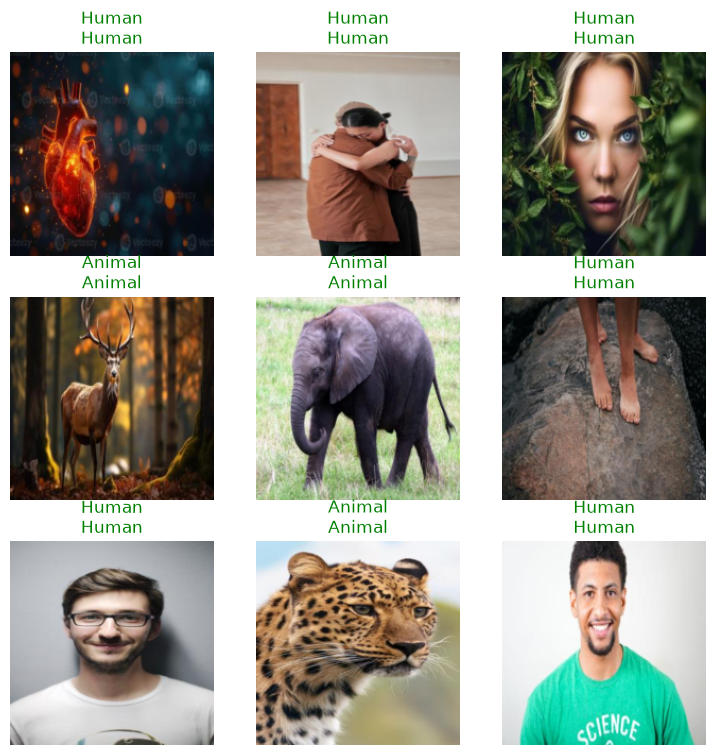

In [13]:
learn.show_results()

This is a: Animal.
Probability it's a Animal: 0.6746
Probability it's a not a Animal: 0.3254


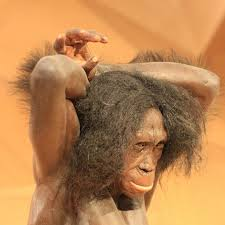

In [26]:
is_human,pred_idx,probs = learn.predict(PILImage.create('monkey.jpeg'))
print(f"This is a: {is_human}.")
print(f"Probability it's a {is_human}: {probs[pred_idx]:.4f}")
print(f"Probability it's a not a {is_human}: {1 - probs[pred_idx]:.4f}")
im = Image.open("monkey.jpeg")
im.to_thumb(256, 256)